In [3]:
# VigilPay | Day 8 — SHAP Explainability
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load XGBoost model
with open('../models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Load test data
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print("✅ Model & data loaded!")
print(f"📐 X_test shape: {X_test.shape}")

C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Model & data loaded!
📐 X_test shape: (56962, 30)


In [2]:
import subprocess
subprocess.run(["pip", "install", "shap"])

CompletedProcess(args=['pip', 'install', 'shap'], returncode=0)

In [4]:
# Create SHAP explainer for XGBoost
print("⏳ Calculating SHAP values... (may take 1-2 minutes)")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated!")
print(f"📐 SHAP values shape: {shap_values.shape}")

⏳ Calculating SHAP values... (may take 1-2 minutes)
✅ SHAP values calculated!
📐 SHAP values shape: (56962, 30)


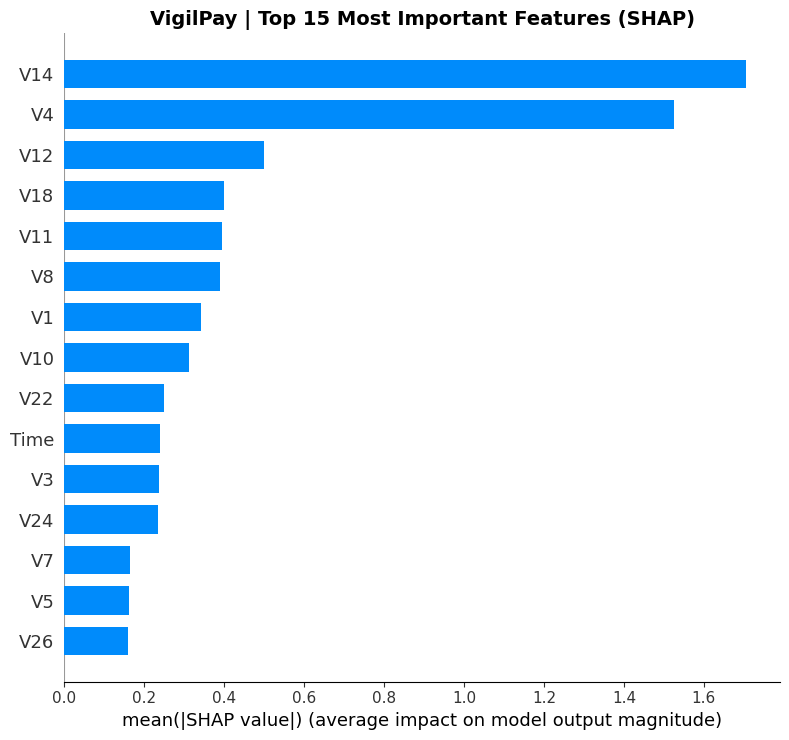

✅ SHAP feature importance chart saved!


In [5]:
# SHAP Summary Plot — most important features overall
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title('VigilPay | Top 15 Most Important Features (SHAP)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ SHAP feature importance chart saved!")

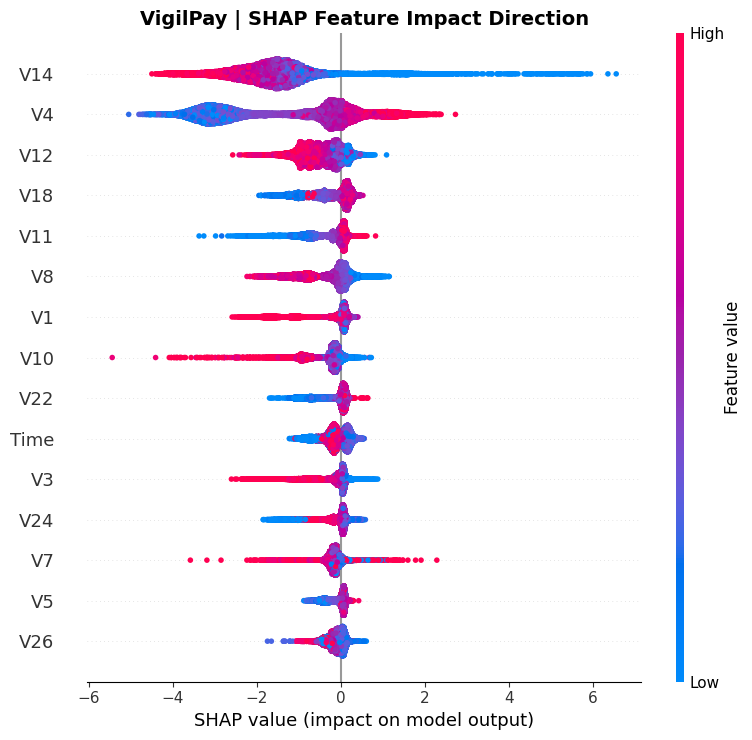

✅ SHAP dot plot saved!


In [6]:
# SHAP dot plot — shows direction of impact too
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title('VigilPay | SHAP Feature Impact Direction',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_dot_plot.png', bbox_inches='tight')
plt.show()
print("✅ SHAP dot plot saved!")

🔍 Explaining fraud transaction at index: 840
📊 Actual label: FRAUD


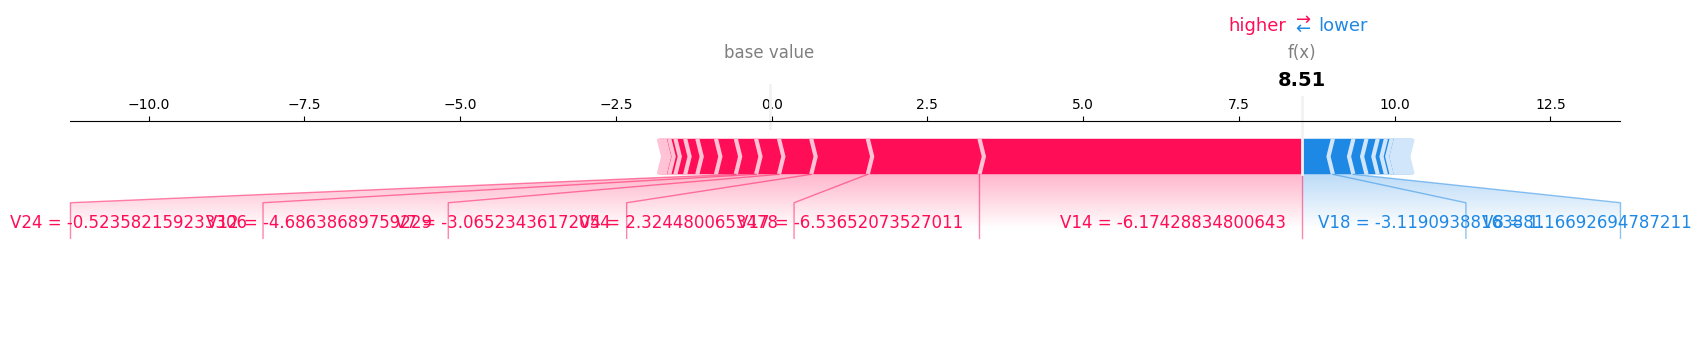

✅ Single transaction explanation saved!


In [7]:
# Explain ONE specific fraud transaction
fraud_indices = y_test[y_test == 1].index.tolist()
fraud_idx = fraud_indices[0]

# Get position in X_test
pos = X_test.index.tolist().index(fraud_idx)

print(f"🔍 Explaining fraud transaction at index: {fraud_idx}")
print(f"📊 Actual label: {'FRAUD' if y_test[fraud_idx]==1 else 'LEGITIMATE'}")

# Force plot saved as HTML
shap.force_plot(
    explainer.expected_value,
    shap_values[pos],
    X_test.iloc[pos],
    matplotlib=True,
    show=False
)
plt.savefig('../data/shap_single_transaction.png', 
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Single transaction explanation saved!")